<a href="https://colab.research.google.com/github/manhnt2115/TH_DeepLearning/blob/main/THDeepLearning_Tuan3(25/05).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

Kích thước dữ liệu gốc: (60000, 28, 28) (10000, 28, 28)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


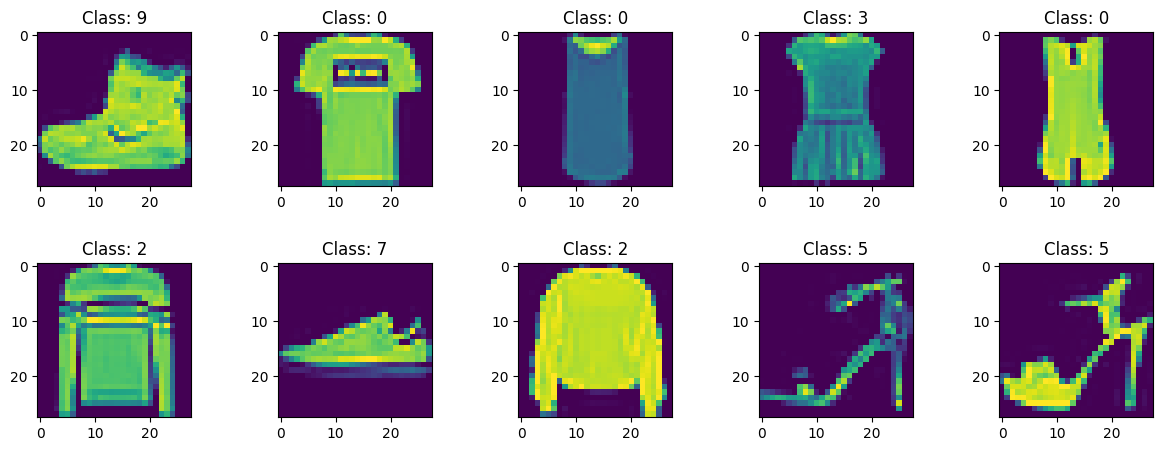

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ---
Epoch 1/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8220 - loss: 0.5049 - val_accuracy: 0.8437 - val_loss: 0.4293
Epoch 2/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8645 - loss: 0.3726 - val_accuracy: 0.8670 - val_loss: 0.3658
Epoch 3/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8793 - loss: 0.3311 - val_accuracy: 0.8822 - val_loss: 0.3299
Epoch 4/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8878 - loss: 0.3074 - val_accuracy: 0.8798 - val_loss: 0.3279
Epoch 5/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8936 - loss: 0.2879 - val_accuracy: 0.8798 - val_loss: 0.3215
Epoch 6/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8990 - loss: 0.2726 - val_accuracy: 0.8837 - val_loss: 0.3162
Epoch 7/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9019 - loss: 0.2613 - val_accuracy: 0.8907 - val_loss: 0.3122
Epoch 8/35
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6m

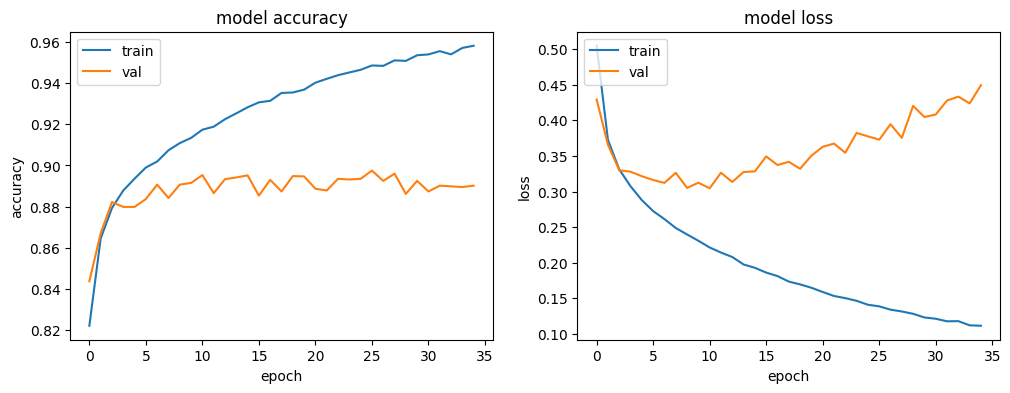


--- Kết quả dự báo thử nghiệm trên tập Test ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ảnh số 0 -> Nhãn dự đoán: 9 | Nhãn thực tế: 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ảnh số 10 -> Nhãn dự đoán: 4 | Nhãn thực tế: 4


In [ ]:
# ==========================================
# BƯỚC 1: NẠP CÁC THƯ VIỆN CẦN THIẾT
# ==========================================
import pandas as pd # [cite: 118]
import numpy as np # [cite: 119]
import matplotlib.pyplot as plt # [cite: 121]

# Nạp thư viện TensorFlow và Keras để xây dựng mạng ANN
import tensorflow as tf #
from tensorflow.keras.models import Sequential # [cite: 125]
from tensorflow.keras.layers import Dense # [cite: 129]

# Gói tiền xử lý chuẩn hóa dữ liệu
from sklearn.preprocessing import MinMaxScaler # [cite: 135]

# ==========================================
# BƯỚC 2: TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU (FASHION MNIST)
# ==========================================
# Tải bộ dữ liệu thời trang Fashion MNIST từ thư viện [cite: 136, 142]
fashion = tf.keras.datasets.fashion_mnist # [cite: 143]
(X_train, y_train), (X_test, y_test) = fashion.load_data() # [cite: 144, 145]
print("Kích thước dữ liệu gốc:", X_train.shape, X_test.shape) # [cite: 145]

# Duỗi ảnh từ cấu trúc 3D (Số ảnh, 28, 28) thành 2D (Số ảnh, 784) để đưa vào mạng ANN [cite: 160]
X_train = X_train.reshape(60000, 784) # [cite: 161]
X_test = X_test.reshape(10000, 784) # [cite: 161]

# Chuẩn hóa các giá trị điểm ảnh (Feature Scaling) về đoạn [0, 1] [cite: 162]
minmax = MinMaxScaler() # [cite: 163]
X_train = minmax.fit_transform(X_train) # [cite: 164]
X_test = minmax.transform(X_test) # [cite: 165]

print('Number of classes:', len(np.unique(y_train))) # [cite: 166]
print('Classes:', np.unique(y_train)) # [cite: 167]

# ==========================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU (VẼ 10 ẢNH ĐẦU TIÊN)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5)) # [cite: 176, 177]
ax = axes.ravel() # [cite: 178]
for i in range(10): # [cite: 179]
    ax[i].imshow(X_train[i].reshape(28, 28)) # [cite: 180]
    ax[i].title.set_text("Class: " + str(y_train[i])) # [cite: 181]
plt.subplots_adjust(hspace=0.5) # [cite: 182]
plt.show() # [cite: 183]

# ==========================================
# BƯỚC 4: XÂY DỰNG KIẾN TRÚC MẠNG NEURAL (ANN)
# ==========================================
# Khởi tạo mô hình tuần tự [cite: 249]
fashion_model = Sequential() # [cite: 251]

# Thêm tầng ẩn (Hidden layer): 256 neuron, hàm kích hoạt ReLU [cite: 252]
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu')) # [cite: 252]

# Thêm tầng đầu ra (Output layer): 10 neuron đại diện 10 lớp, hàm kích hoạt Softmax [cite: 253, 254]
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax')) # [cite: 254]

# Biên dịch mô hình (Cấu hình Optimizer, Hàm Loss và Thang đo đánh giá) [cite: 255]
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # [cite: 255]

# Hiển thị bảng tóm tắt cấu trúc mạng [cite: 256]
fashion_model.summary() # [cite: 257]

# ==========================================
# BƯỚC 5: HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\n--- Bắt đầu huấn luyện mô hình ---")
# Tiến hành huấn luyện trong 20 chu kỳ (epochs) [cite: 273]
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=35, verbose=1) # [cite: 273]

# ==========================================
# BƯỚC 6: ĐÁNH GIÁ MÔ HÌNH QUA ĐỒ THỊ LOSS & ACCURACY
# ==========================================
# 1. Vẽ đồ thị Độ chính xác (Accuracy) [cite: 348]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy']) # [cite: 349]
plt.plot(model_fit.history['val_accuracy']) # [cite: 350]
plt.title('model accuracy') # [cite: 350]
plt.ylabel('accuracy') # [cite: 351]
plt.xlabel('epoch') # [cite: 352]
plt.legend(['train', 'val'], loc='upper left') # [cite: 353]

# 2. Vẽ đồ thị Độ mất mát (Loss) [cite: 370]
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss']) # [cite: 373]
plt.plot(model_fit.history['val_loss']) # [cite: 374]
plt.title('model loss') # [cite: 375]
plt.ylabel('loss') # [cite: 376]
plt.xlabel('epoch') # [cite: 377]
plt.legend(['train', 'val'], loc='upper left') # [cite: 378]
plt.show() # [cite: 353, 378]

# ==========================================
# BƯỚC 7: DỰ BÁO TRÊN DỮ LIỆU KIỂM THỬ (TEST DATA)
# ==========================================
print("\n--- Kết quả dự báo thử nghiệm trên tập Test ---")
# Dự báo nhãn cho ảnh đầu tiên (chỉ mục số 0) [cite: 396]
print("Ảnh số 0 -> Nhãn dự đoán:", np.argmax(fashion_model.predict(X_test)[0]), "| Nhãn thực tế:", y_test[0]) # [cite: 396]

# Dự báo nhãn cho ảnh tại chỉ mục số 10 [cite: 397]
print("Ảnh số 10 -> Nhãn dự đoán:", np.argmax(fashion_model.predict(X_test)[10]), "| Nhãn thực tế:", y_test[10]) # [cite: 397]

BaiTap1_ANN

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Kích thước dữ liệu gốc: (50000, 32, 32, 3) (10000, 32, 32, 3)
Số lượng lớp phân loại: 10


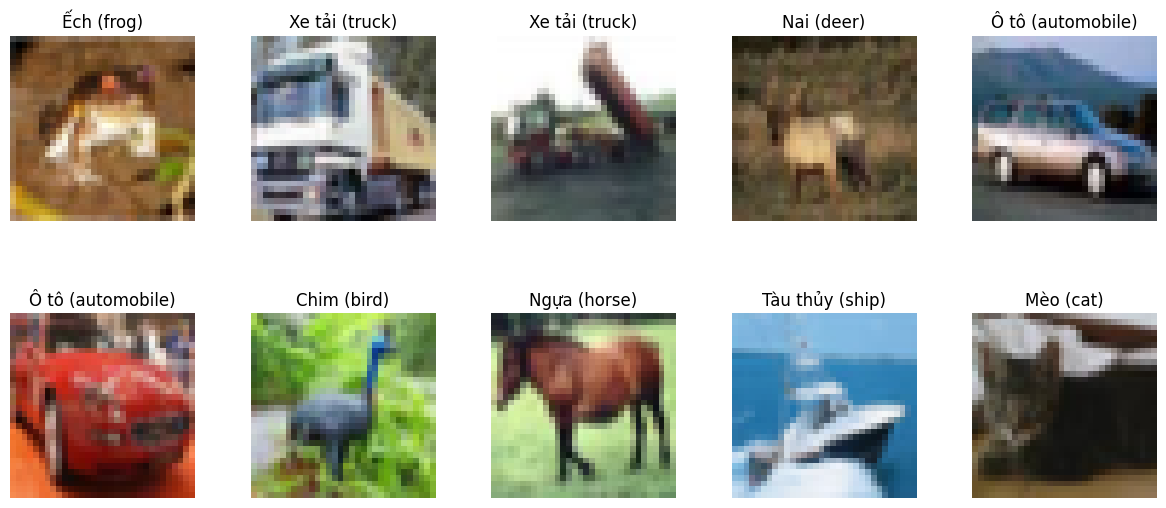

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình trên dữ liệu CIFAR-10 ---
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.3268 - loss: 1.8499 - val_accuracy: 0.3728 - val_loss: 1.7295
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4021 - loss: 1.6638 - val_accuracy: 0.3940 - val_loss: 1.7181
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.4320 - loss: 1.5823 - val_accuracy: 0.3930 - val_loss: 1.6912
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4519 - loss: 1.5228 - val_accuracy: 0.4516 - val_loss: 1.5547
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.4713 - loss: 1.4778 - val_accuracy: 0.4522 - val_loss: 1.5506
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4828 - loss: 1.4459 - val_accuracy: 0.4534 - val_loss: 1.5378
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.4960 - loss: 1.4134 - val_accuracy: 0.4852 - val_loss: 1.4734
Epoch 8/20
704/704 ━━━━━━━━━━━━━

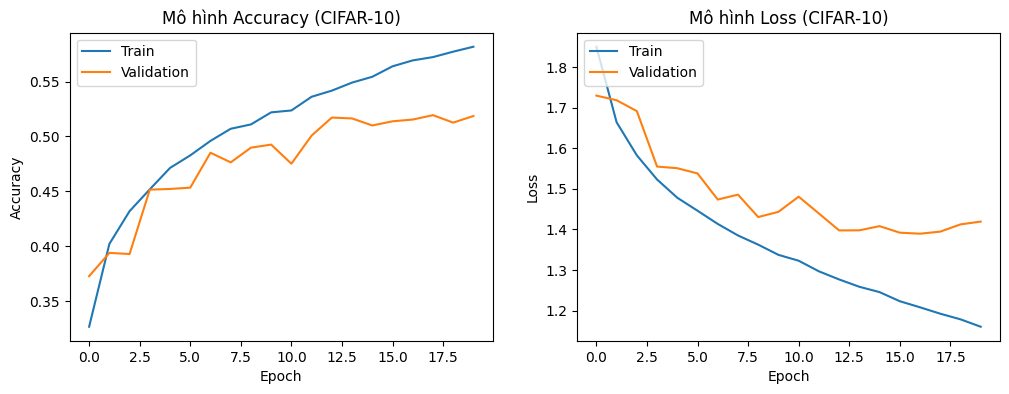


--- Kết quả dự báo thử nghiệm ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Ảnh số 0 -> Dự đoán: Mèo (cat) | Thực tế: Mèo (cat)
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Ảnh số 10 -> Dự đoán: Máy bay (airplane) | Thực tế: Máy bay (airplane)


In [14]:
# ==========================================
# BƯỚC 1: NẠP CÁC THƯ VIỆN CẦN THIẾT
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

# Tên của 10 nhãn tương ứng với các lớp trong CIFAR-10
class_names = ['Máy bay (airplane)', 'Ô tô (automobile)', 'Chim (bird)', 'Mèo (cat)', 'Nai (deer)',
               'Chó (dog)', 'Ếch (frog)', 'Ngựa (horse)', 'Tàu thủy (ship)', 'Xe tải (truck)']

# ==========================================
# BƯỚC 2: TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU (CIFAR-10)
# ==========================================
# Tải bộ dữ liệu CIFAR-10 tích hợp sẵn
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước dữ liệu gốc:", X_train.shape, X_test.shape)
# Đầu ra sẽ là: (50000, 32, 32, 3) và (10000, 32, 32, 3)

# Chuyển đổi ma trận nhãn y từ dạng 2D sang 1D (vector phẳng) để khớp với hàm loss
y_train = y_train.flatten()
y_test = y_test.flatten()

# Duỗi ảnh từ cấu trúc 4D (Số ảnh, 32, 32, 3) thành 2D (Số ảnh, 3072) để đưa vào mạng ANN
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

# Chuẩn hóa các giá trị điểm ảnh (Feature Scaling) về đoạn [0, 1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Số lượng lớp phân loại:', len(np.unique(y_train)))

# ==========================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU (HIỂN THỊ 10 ẢNH ĐẦU TIÊN)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()
for i in range(10):
    # Khôi phục lại định dạng ảnh 32x32x3 để hiển thị ảnh màu đầy đủ
    ax[i].imshow(X_train[i].reshape(32, 32, 3))
    ax[i].title.set_text(class_names[y_train[i]])
    ax[i].axis('off')
plt.subplots_adjust(hspace=0.5)
plt.show()

# ==========================================
# BƯỚC 4: XÂY DỰNG KIẾN TRÚC MẠNG NEURAL (ANN)
# ==========================================
fashion_model = Sequential()

# Thêm tầng ẩn (Hidden layer): Vì dữ liệu ảnh màu phức tạp hơn, ta tăng lên 512 neuron
fashion_model.add(Dense(input_dim=X_train.shape[1], units=512, kernel_initializer='uniform', activation='relu'))

# Thêm tầng ẩn thứ hai (Tùy chọn bổ sung giúp mạng học tốt hơn, có thể giữ nguyên 1 tầng như bài lab)
fashion_model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))

# Thêm tầng đầu ra (Output layer): 10 neuron đại diện cho 10 lớp đối tượng
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị bảng tóm tắt cấu trúc mạng
fashion_model.summary()

# ==========================================
# BƯỚC 5: HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\n--- Bắt đầu huấn luyện mô hình trên dữ liệu CIFAR-10 ---")
# Huấn luyện trong 20 chu kỳ (epochs), cắt ra 10% dữ liệu để validation
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)

# ==========================================
# BƯỚC 6: ĐÁNH GIÁ MÔ HÌNH QUA ĐỒ THỊ LOSS & ACCURACY
# ==========================================
plt.figure(figsize=(12, 4))

# Đồ thị Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train')
plt.plot(model_fit.history['val_accuracy'], label='Validation')
plt.title('Mô hình Accuracy (CIFAR-10)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Đồ thị Độ mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train')
plt.plot(model_fit.history['val_loss'], label='Validation')
plt.title('Mô hình Loss (CIFAR-10)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# ==========================================
# BƯỚC 7: DỰ BÁO THỬ NGHIỆM TRÊN TẬP TEST
# ==========================================
print("\n--- Kết quả dự báo thử nghiệm ---")
# Dự báo cho ảnh đầu tiên trong tập test (chỉ mục số 0)
pred_0 = np.argmax(fashion_model.predict(X_test)[0])
print(f"Ảnh số 0 -> Dự đoán: {class_names[pred_0]} | Thực tế: {class_names[y_test[0]]}")

# Dự báo cho ảnh tại chỉ mục số 10
pred_10 = np.argmax(fashion_model.predict(X_test)[10])
print(f"Ảnh số 10 -> Dự đoán: {class_names[pred_10]} | Thực tế: {class_names[y_test[10]]}")